In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df1_raw = pd.read_csv('store_checkout_queues.csv')
df2_raw = pd.read_csv('store_stores.csv')

In [3]:
df1_raw.head(1)

,checks_number,store_uuid,employees_id,quantity,selling_price,checkout_id,start_operation_dt,end_operation_dt
0,16387396,tdel8oni-egjd-ddij-u7k4-ccxxh7ho12,103936,1.0,179.0,1.0,"2024-11-20 09:09:02,996","2024-11-20 09:09:32,996"


In [4]:
df1_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064703 entries, 0 to 1064702
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   checks_number       1064703 non-null  int64  
 1   store_uuid          1064703 non-null  object 
 2   employees_id        1064703 non-null  int64  
 3   quantity            1064703 non-null  float64
 4   selling_price       1064703 non-null  float64
 5   checkout_id         1064703 non-null  float64
 6   start_operation_dt  1064703 non-null  object 
 7   end_operation_dt    1064703 non-null  object 
dtypes: float64(3), int64(2), object(3)
memory usage: 65.0+ MB


In [5]:
# Преобразование типов в количестве покупок и id касс (из float в integer)
df1_raw = df1_raw.astype({'checkout_id': 'Int64','quantity': 'Int64'})

# Замена "," на "." и преобразование текстового формата в date_time для времени начала и окончания операций
df1_raw['start_operation_dt'] = pd.to_datetime(df1_raw['start_operation_dt'].str.replace(',', '.'), format='%Y-%m-%d %H:%M:%S.%f')
df1_raw['end_operation_dt'] = pd.to_datetime(df1_raw['end_operation_dt'].str.replace(',', '.'), format='%Y-%m-%d %H:%M:%S.%f')

df1_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064703 entries, 0 to 1064702
Data columns (total 8 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   checks_number       1064703 non-null  int64         
 1   store_uuid          1064703 non-null  object        
 2   employees_id        1064703 non-null  int64         
 3   quantity            1064703 non-null  Int64         
 4   selling_price       1064703 non-null  float64       
 5   checkout_id         1064703 non-null  Int64         
 6   start_operation_dt  1064703 non-null  datetime64[ns]
 7   end_operation_dt    1064703 non-null  datetime64[ns]
dtypes: Int64(2), datetime64[ns](2), float64(1), int64(2), object(1)
memory usage: 67.0+ MB


In [6]:
df1_raw.head(1)

,checks_number,store_uuid,employees_id,quantity,selling_price,checkout_id,start_operation_dt,end_operation_dt
0,16387396,tdel8oni-egjd-ddij-u7k4-ccxxh7ho12,103936,1,179.0,1,2024-11-20 09:09:02.996,2024-11-20 09:09:32.996


In [7]:
df2_raw.head(1)

,store_id,store_uuid
0,10008,712f0db6-2493-11e9-95e8-0050569efd74


In [8]:
df2_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68 entries, 0 to 67
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   store_id    68 non-null     int64 
 1   store_uuid  68 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


In [9]:
# Проверка на нуллы (NaN) в обеих таблицах
pd.concat([df1_raw.isna().sum().rename('df1_raw'), df2_raw.isna().sum().rename('df2_raw')], axis=1)

,df1_raw,df2_raw
checks_number,0.0,NaN
store_uuid,0.0,0.0
employees_id,0.0,NaN
quantity,0.0,NaN
selling_price,0.0,NaN
checkout_id,0.0,NaN
start_operation_dt,0.0,NaN
end_operation_dt,0.0,NaN
store_id,NaN,0.0


In [10]:
# Нуллы в пределах каждой таблицы не обнаружены - объединяем обе таблицы
df_merged = pd.merge(df1_raw, df2_raw, on='store_uuid', how='left')
df_merged.head(1)

,checks_number,store_uuid,employees_id,quantity,selling_price,checkout_id,start_operation_dt,end_operation_dt,store_id
0,16387396,tdel8oni-egjd-ddij-u7k4-ccxxh7ho12,103936,1,179.0,1,2024-11-20 09:09:02.996,2024-11-20 09:09:32.996,2128


In [11]:
# Избавляемся от store_uuid и меняем порядок колонок согласно заданному условию
new_col_order = ['checks_number', 'store_id', 'employees_id', 'quantity', 'selling_price', 'checkout_id', 'start_operation_dt', 'end_operation_dt']
df_new = df_merged[new_col_order]
df_new.head(1)

,checks_number,store_id,employees_id,quantity,selling_price,checkout_id,start_operation_dt,end_operation_dt
0,16387396,2128,103936,1,179.0,1,2024-11-20 09:09:02.996,2024-11-20 09:09:32.996


In [12]:
# ФИльтруем DF только по магазинам 2668 и 2952
df_filtered = df_new[df_new['store_id'].isin([2668, 2952])]
df_filtered

,checks_number,store_id,employees_id,quantity,selling_price,checkout_id,start_operation_dt,end_operation_dt
22075,6088680,2952,140682,1,238.00,1,2024-12-08 16:53:11.996,2024-12-08 16:53:34.996
22076,8390558,2952,140682,1,43.00,1,2024-12-11 11:09:38.996,2024-12-11 11:09:49.996
22077,8390563,2952,140682,1,389.61,1,2024-12-11 11:12:35.996,2024-12-11 11:13:02.996
22078,8390565,2952,140682,1,399.99,1,2024-12-11 11:13:32.000,2024-12-11 11:14:14.000
22079,324639,2952,140682,1,219.00,1,2024-12-01 08:57:51.996,2024-12-01 08:58:20.000
...,...,...,...,...,...,...,...,...
1050377,16632957,2952,140682,3,134.00,1,2024-12-21 13:02:19.996,2024-12-21 13:02:41.000
1050378,18215204,2952,140682,3,474.00,1,2024-12-23 19:05:58.000,2024-12-23 19:06:25.000
1050379,18215212,2952,140682,3,169.00,1,2024-12-23 19:15:52.000,2024-12-23 19:16:20.000
1050380,18215223,2952,140682,3,289.05,1,2024-12-23 19:21:31.000,2024-12-23 19:22:29.000


In [13]:
# Вычисляем наличие очередей в кассах по двум магазинам сразу
# (условием наличия очереди считаем начало следующей операции на кассе в интервале 0-5 секунд от окончания предыдущей) 

# Сортировка по магазину, кассе и времени начала операции
df_filtered = df_filtered.sort_values(by=['store_id', 'checkout_id', 'start_operation_dt'])

# Сдвиг времени окончания предыдущей операции на 1 строку вниз - чтобы далее сравнить с началом следующей
df_filtered['prev_end_dt'] = (df_filtered.groupby(['store_id', 'checkout_id'])['end_operation_dt'].shift(1))

# Вычисление интервала между предыдущей и следующей операциями (в секундах)
df_filtered['gap_seconds'] = (df_filtered['start_operation_dt'] - df_filtered['prev_end_dt']).dt.total_seconds()

# Установка флага наличия очереди: интервал между предыдущей и следующей операциями от 0 до 5 секунд
df_filtered['queue_flag'] = df_filtered['gap_seconds'].between(0, 5)

# Вывод количества случаев очереди
queue_count = df_filtered['queue_flag'].sum()

if queue_count == 0:
    print("Очередь отсутствовала")
else:
    print(f"Очередь (<=5 сек интервал между операциями на одной кассе) в {int(queue_count)} случаях")

Очередь (<=5 сек интервал между операциями на одной кассе) в 6553 случаях


In [14]:
# Вычисляем долю случаев очереди на каждой кассе каждого магазина

# Общее количество операций
total_operations = df_filtered.shape[0]

# Доля случаев с очередью (всего по датасету)
queue_share = (queue_count / total_operations) * 100

# Подсчет по магазинам
store_operations = df_filtered.groupby('store_id').size()
store_queue = df_filtered[df_filtered['queue_flag']].groupby('store_id').size()

# Доля очередей по каждому магазину
store_queue_share = (store_queue / store_operations * 100).fillna(0).sort_values(ascending=False)

# Общее количество операций по каждой кассе в каждом магазине
checkout_operations = df_filtered.groupby(['store_id', 'checkout_id']).size()

# Количество операций с очередью по каждой кассе
checkout_queue = df_filtered[df_filtered['queue_flag']].groupby(['store_id', 'checkout_id']).size()

# Доля очередей по кассам каждого магазина
checkout_queue_share = (checkout_queue / checkout_operations * 100).fillna(0).sort_values(ascending=False)

# Общая сводка
print(f"Очередь фиксировалась в {queue_share:.2f}% случаев всех операций "
    f"(магазин 2668: {store_queue_share.get(2668, 0):.2f}%, магазин 2952: {store_queue_share.get(2952, 0):.2f}%)")

# Доля очередей по кассам каждого магазина
print("\nПроцент очередей по каждой кассе каждого магазина:")

# Группировка по магазину
for store_id in sorted(store_queue_share.index, key=lambda x: -store_queue_share[x]):
    print(f"\n Магазин {store_id}")
    
    # Фильтрация и сортировка касс этого магазина
    store_checkouts = {checkout_id: percentage for (s_id, checkout_id), percentage in checkout_queue_share.items() if s_id == store_id}
    sorted_checkouts = sorted(store_checkouts.items(), key=lambda x: -x[1])
    
    for checkout_id, percentage in sorted_checkouts:
        print(f" Касса {checkout_id} — {percentage:.2f}%")

Очередь фиксировалась в 12.96% случаев всех операций (магазин 2668: 13.86%, магазин 2952: 12.12%)

Процент очередей по каждой кассе каждого магазина:

 Магазин 2668
 Касса 2 — 16.04%
 Касса 1 — 14.49%
 Касса 3 — 10.00%
 Касса 13 — 0.20%
 Касса 11 — 0.19%
 Касса 12 — 0.17%

 Магазин 2952
 Касса 2 — 21.86%
 Касса 3 — 21.40%
 Касса 1 — 14.08%
 Касса 11 — 0.92%
 Касса 13 — 0.75%
 Касса 12 — 0.63%


In [15]:
# Формирование финальной структуры данных перед визуализацией (DF "queue_filtered")

# Добавляем столбцы: день недели, час, дата
df_filtered['weekday'] = df_filtered['start_operation_dt'].dt.day_name()
df_filtered['hour'] = df_filtered['start_operation_dt'].dt.hour
df_filtered['date'] = df_filtered['start_operation_dt'].dt.date

# Фильтруем только операции с очередью
queue_df = df_filtered[df_filtered['queue_flag']]

# Группировка по магазину, кассе, дате, дню недели и часу
queue_by_time = (queue_df.groupby(['store_id', 'checkout_id', 'date', 'weekday', 'hour']).size().reset_index(name='queue_count'))

# Фильтрация: оставить только строки с ≥ 5 случаев очередей
queue_filtered = queue_by_time[queue_by_time['queue_count'] >= 5]

# Сортировка по количеству случаев очередей по убыванию
queue_filtered = queue_filtered.sort_values(by='queue_count', ascending=False)

queue_filtered

,store_id,checkout_id,date,weekday,hour,queue_count
82,2668,1,2024-12-02,Monday,6,25
1180,2952,2,2024-12-06,Friday,18,24
738,2668,2,2024-12-22,Sunday,13,21
1030,2952,1,2024-12-18,Wednesday,20,20
947,2952,1,2024-12-11,Wednesday,16,19
...,...,...,...,...,...,...
489,2668,2,2024-11-30,Saturday,14,5
941,2952,1,2024-12-11,Wednesday,10,5
1167,2952,2,2024-12-04,Wednesday,20,5
493,2668,2,2024-11-30,Saturday,18,5


In [16]:
# Функция для визуализации очередей по кассам каждого магазина: сначала по дням недели и часам, и затем по дням недели, датам и часам

def visualize_all(store_ids, cmap_weekday='YlOrBr', cmap_date='Oranges'):
    for store_id in store_ids:
        store_df = queue_filtered[queue_filtered['store_id'] == store_id].copy()

        if store_df.empty:
            print(f"Нет данных для магазина {store_id}")
            continue

        checkout_ids = sorted(store_df['checkout_id'].unique())

        for checkout_id in checkout_ids:
            heat_df = store_df[store_df['checkout_id'] == checkout_id].copy()

            if heat_df.empty or heat_df['queue_count'].sum() < 5:
                continue

            # Первая визуализация — по дням недели и часам
            pivot_weekday = (heat_df.groupby(['weekday', 'hour'])['queue_count'].sum().unstack().fillna(0))
            weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            pivot_weekday = pivot_weekday.reindex(weekday_order)
            pivot_weekday = pivot_weekday.replace(0, np.nan)
            pivot_weekday = pivot_weekday.dropna(how='all')  # Удаление пустых дней

            plt.figure(figsize=(14, 6))
            sns.heatmap(pivot_weekday, cmap=cmap_weekday, annot=True, fmt='.0f', linewidths=0.5, linecolor='gray')
            plt.title(f"Очереди ≥5 шт. в час, по дням недели и часам, Касса {checkout_id} - Магазин {store_id}")
            plt.ylabel("День недели")
            plt.xlabel("Час")
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

            # Вторая визуализация — по дням недели, дате и часам
            heat_df['weekday_num'] = pd.to_datetime(heat_df['date']).dt.weekday
            heat_df['weekday_label'] = pd.to_datetime(heat_df['date']).dt.strftime('%a')
            heat_df['date_str'] = pd.to_datetime(heat_df['date']).dt.strftime('%Y-%m-%d')
            heat_df['date_label'] = heat_df['weekday_label'] + ' ' + heat_df['date_str']

            ordered_labels = (heat_df.sort_values(['weekday_num', 'date'])['date_label'].drop_duplicates().tolist())
            heat_df['date_label'] = pd.Categorical(heat_df['date_label'], categories=ordered_labels, ordered=True)
            pivot_date = heat_df.pivot_table(index='date_label', columns='hour', values='queue_count', fill_value=0, observed=False
            ).replace(0, np.nan)
            pivot_date = pivot_date.dropna(how='all')  # Удаление пустых дат

            plt.figure(figsize=(16, 8))
            sns.heatmap(pivot_date, cmap=cmap_date, annot=True, fmt='.0f', linewidths=0.5, linecolor='gray')
            plt.title(f"Очереди ≥5 шт. в час, по дням недели, датам и часам, Касса {checkout_id} - Магазин {store_id}")
            plt.ylabel("День недели и дата")
            plt.xlabel("Час")
            plt.xticks(rotation=0)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()

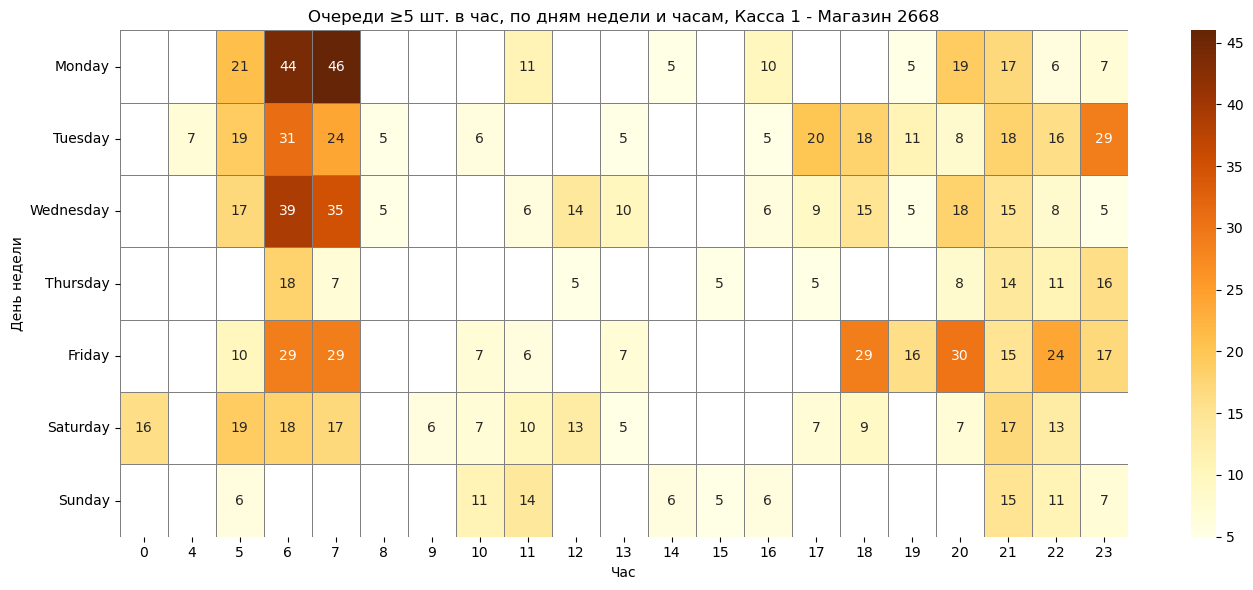

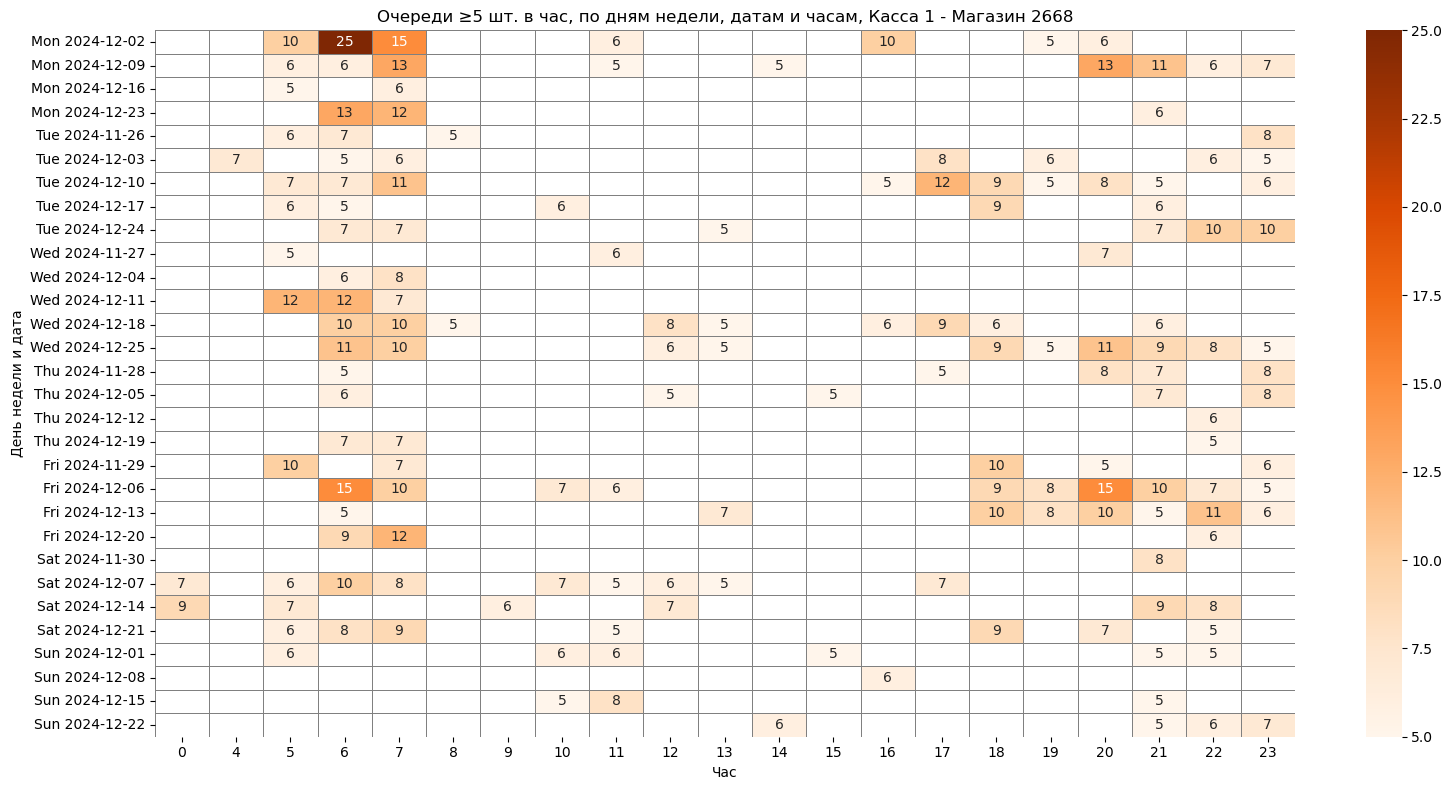

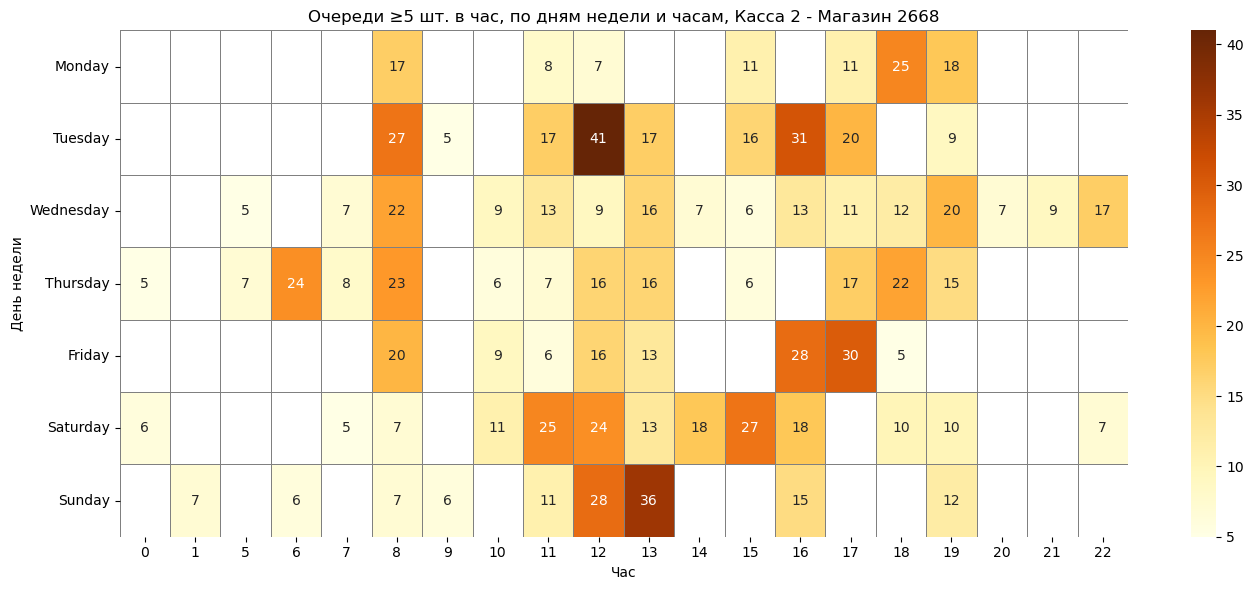

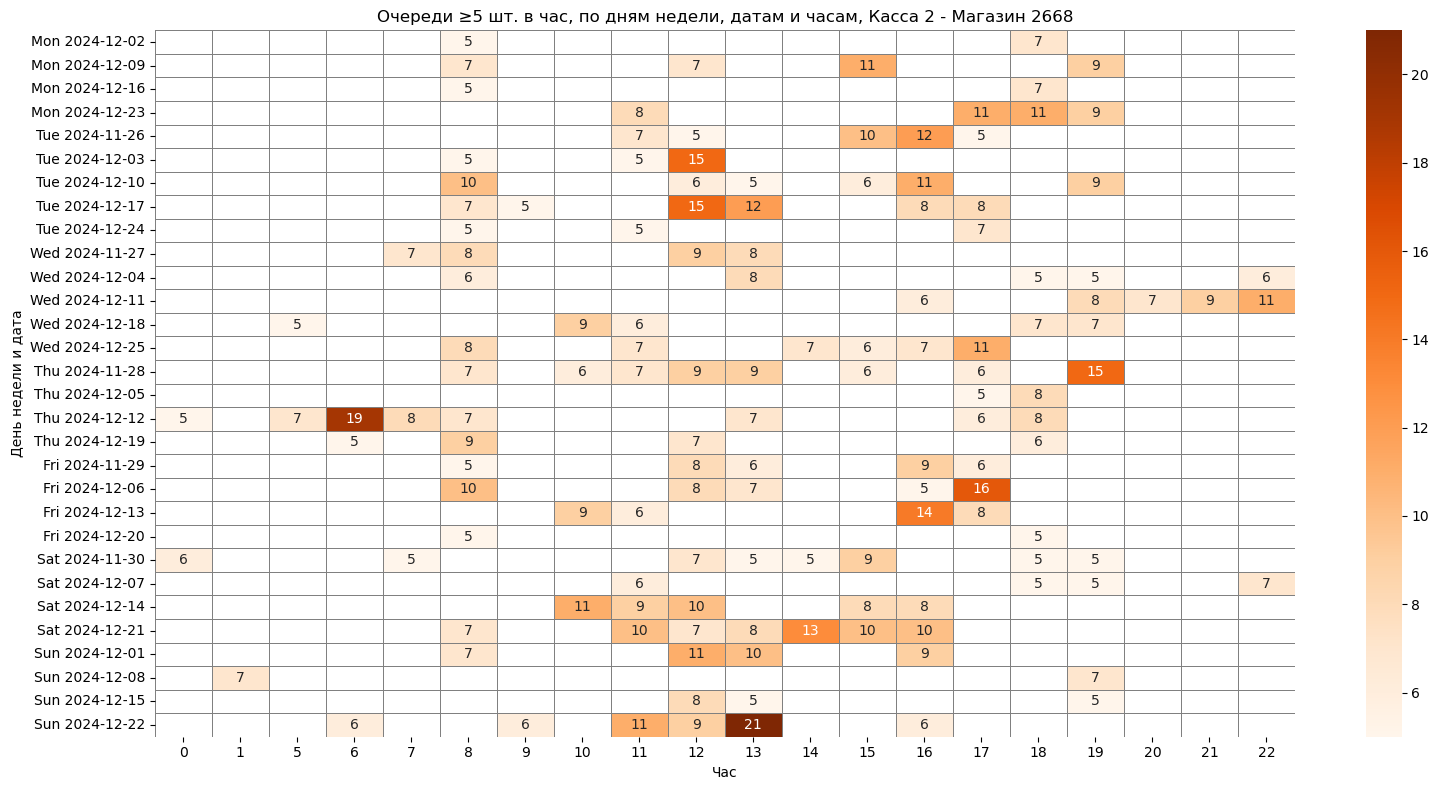

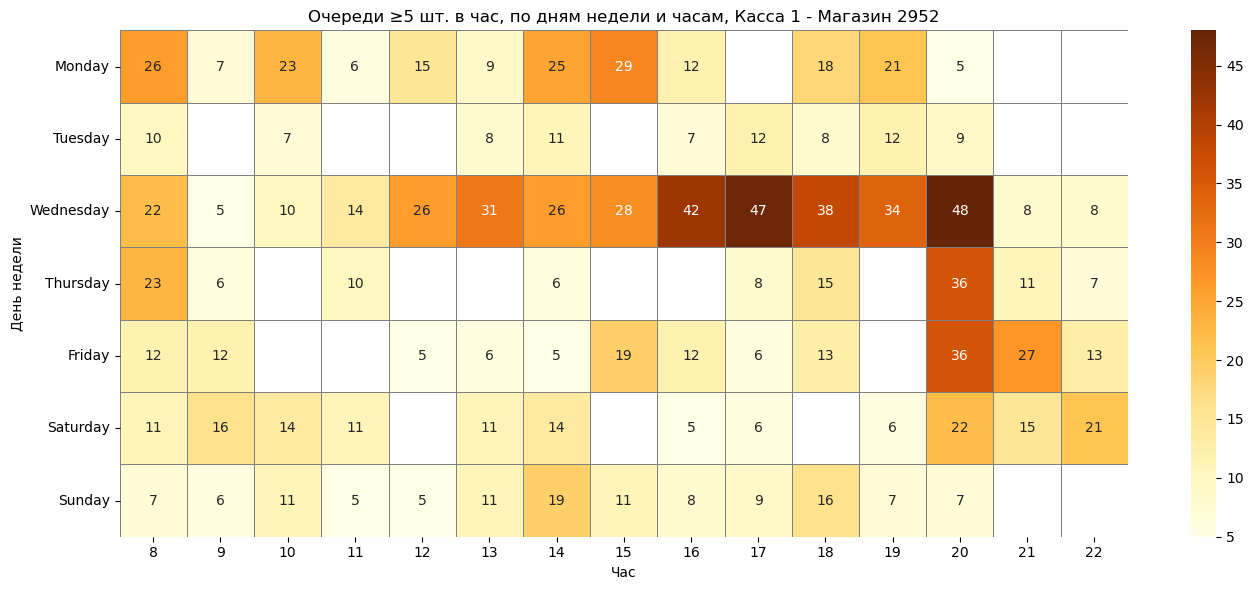

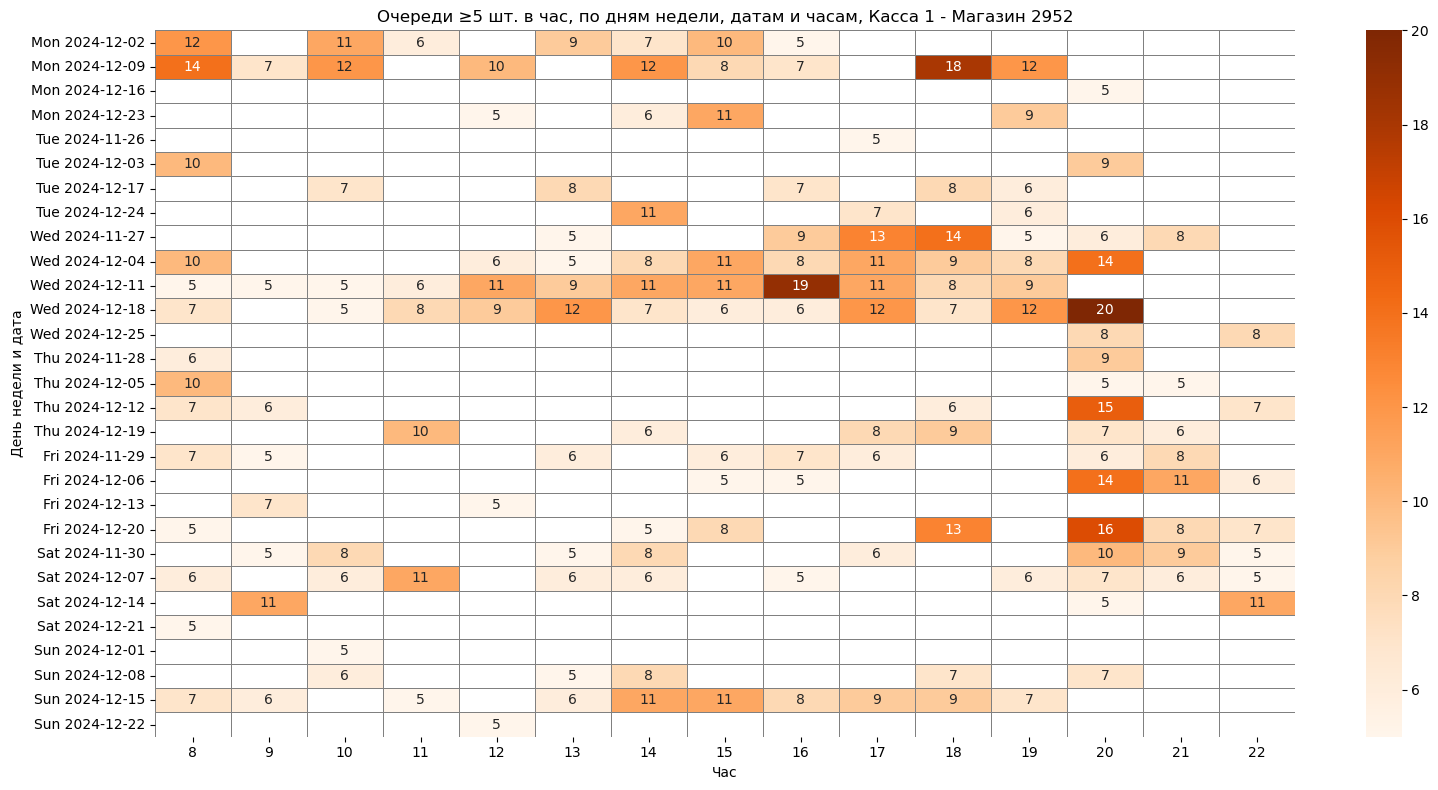

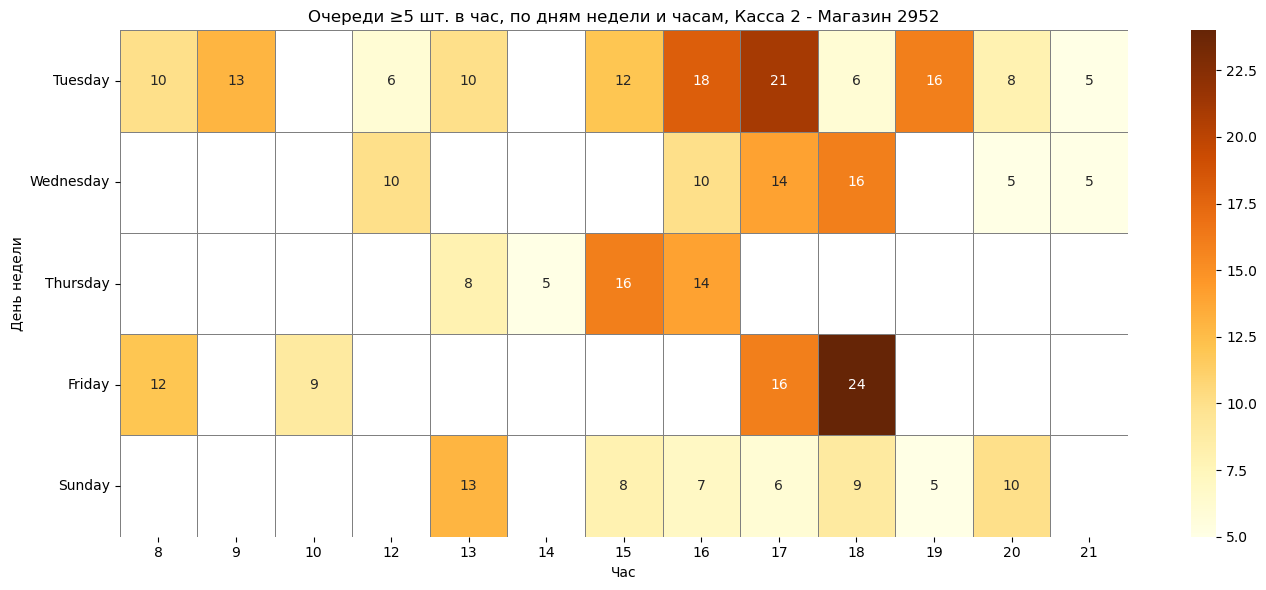

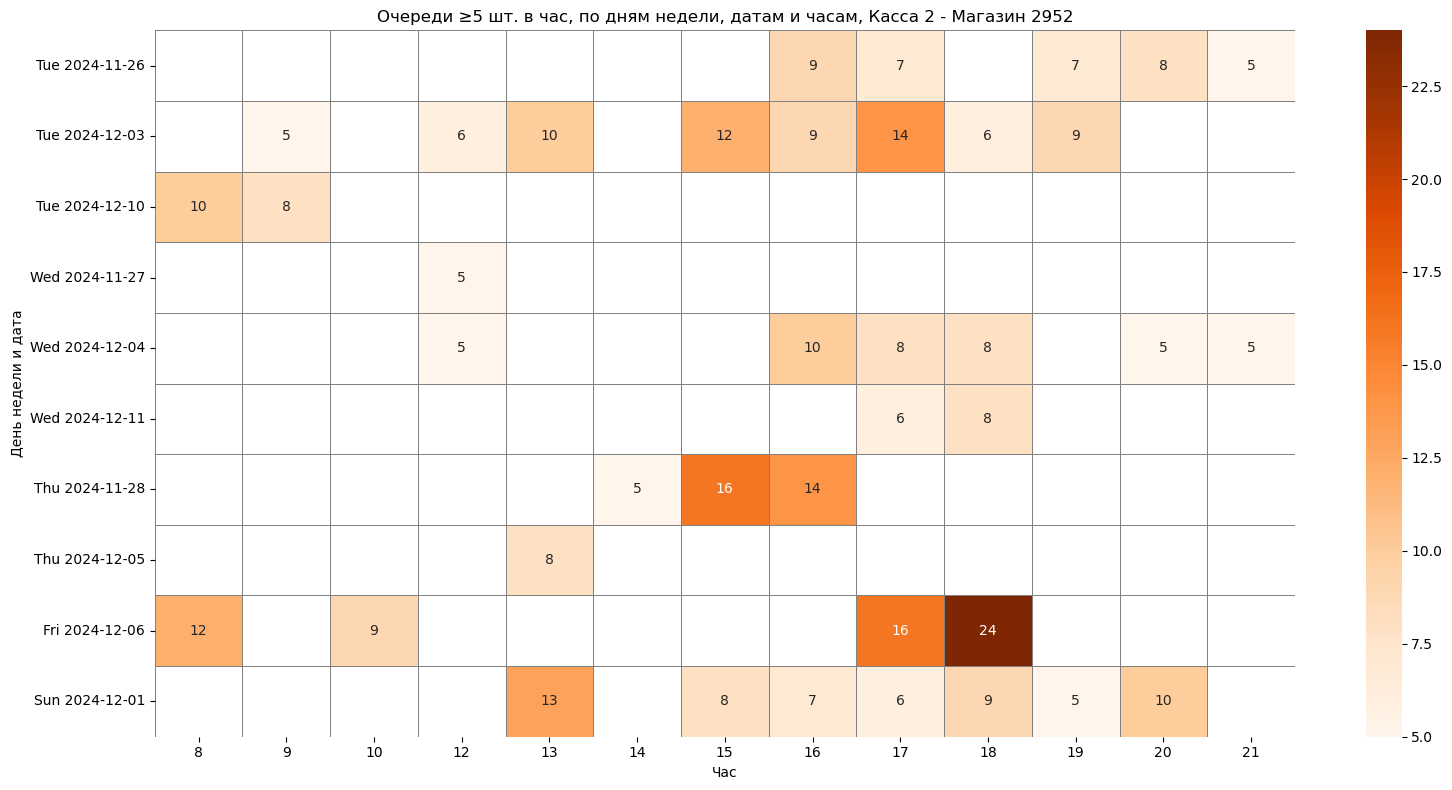

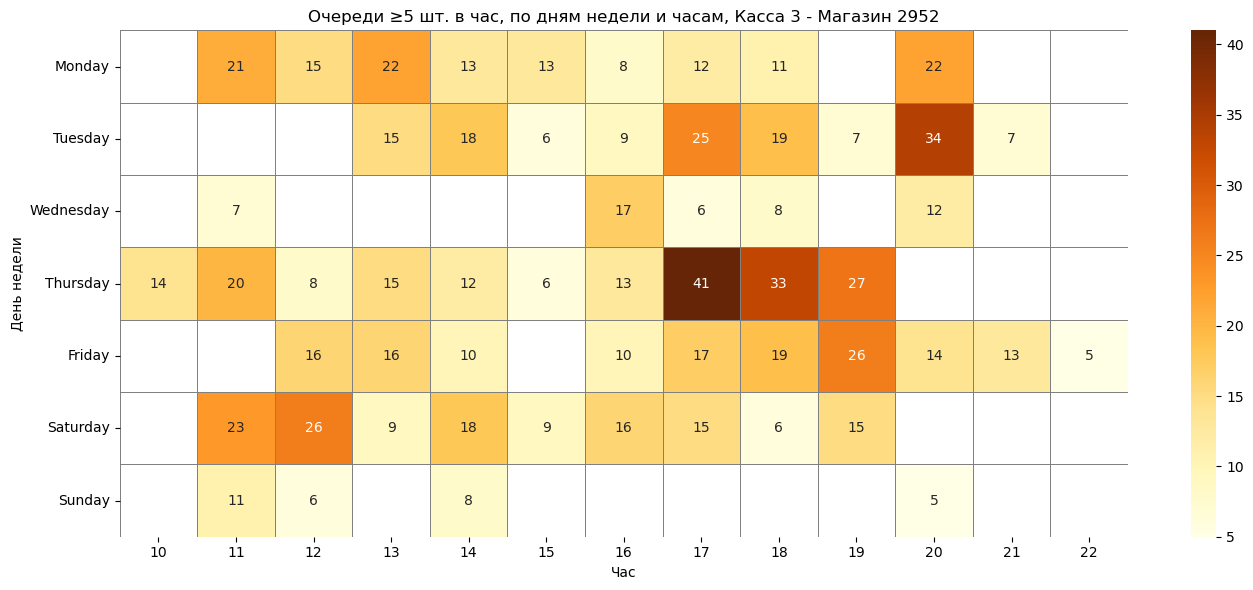

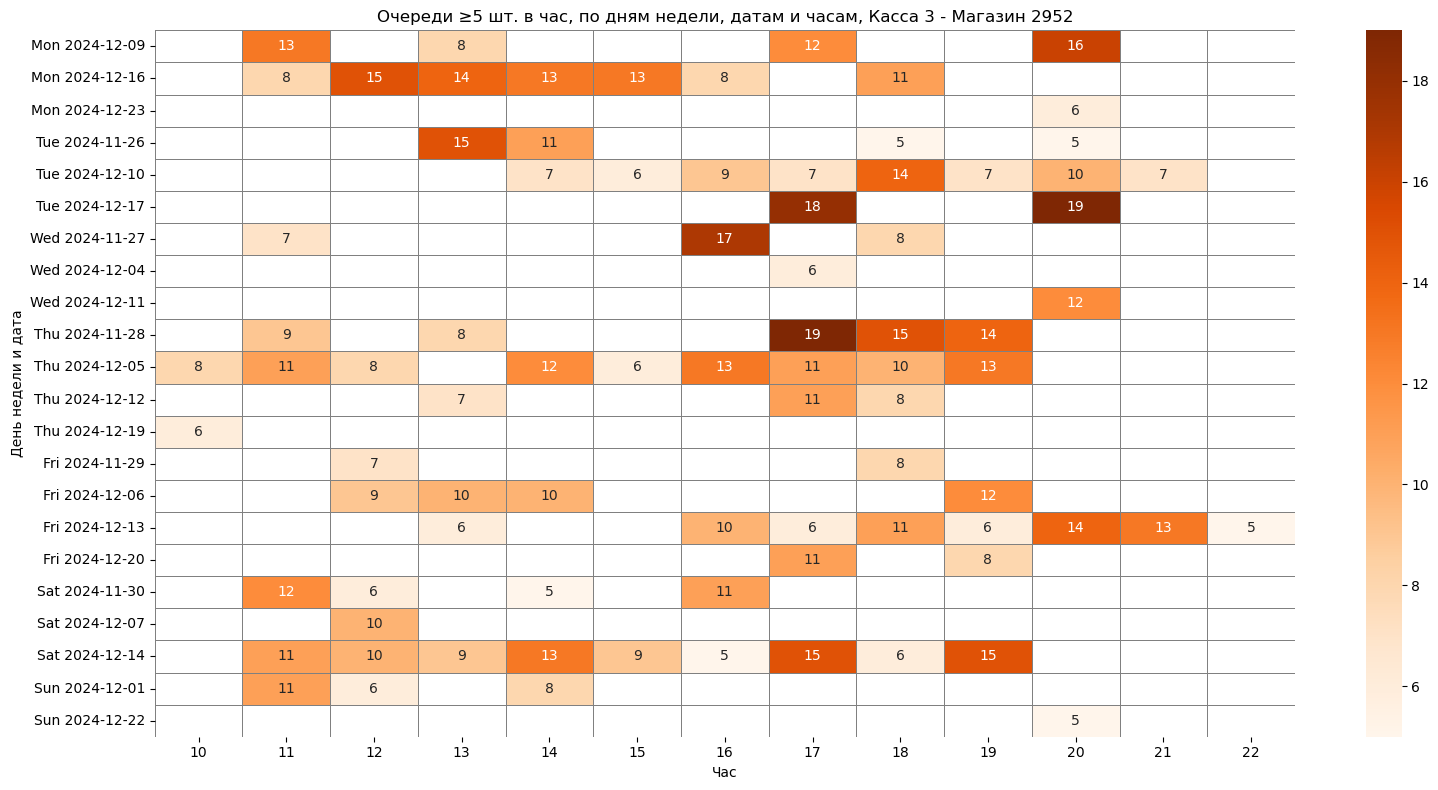

In [17]:
visualize_all([2668, 2952])

# Аналитический отчёт по очередям на кассах магазинов 2668 и 2952

_Анализ охватывает более 1 млн транзакций. Очередью считаются операции с интервалом между клиентами на одной кассе ≤5 секунд. В отчёт включены случаи, где за час было ≥5 таких последовательностей._


## Общая загруженность по магазинам

Магазин 2668: около 25 200 операций, из них 3 493 — очереди. Это 13.86% от всех операций.  
Магазин 2952: около 25 300 операций, из них 3 060 — очереди. Это 12.12%.  
Итого: из ~50 500 операций было 6 553 очередей — 12.96% в среднем.
Очереди фиксировались примерно в каждой восьмой операции.


## Перегруженность касс

В магазине 2668:  
– Касса 2: 16.04% очередей  
– Касса 1: 14.49%  
– Касса 3: 10.00%  
– Кассы 11, 12, 13: менее 0.2%

В магазине 2952:  
– Касса 2: 21.86%  
– Касса 3: 21.40%  
– Касса 1: 14.08%  
– Кассы 11, 12, 13: менее 1%

Кассы 2 и 3 в магазине 2952 — наибольшая перегрузка.


## Временные паттерны по обоим магазинам

– Утро (6–8): активность особенно по понедельникам, преимущественно касса 1, особенно в магазине 2668   
– Вечер (16–20): выраженные пики в среду и пятницу на всех кассах, но особенно на кассах 2 и 3 (более выраженно в магазине 2952)   
– Выходные (суббота и воскресенье): всплеск очередей в кассах 2 и 3, наиболее выражены в магазине 2952   
– Самые загруженные дни: 06.12, 18.12 и 22.12 по всем кассам обоих магазинов - возможно, дни маркетинговых промо акций.   

Наиболее проблемное время — период «после работы».

---

## Рекомендации

1. Гибкое расписание персонала  
– Усиление смен в среду и пятницу с 16:00 до 20:00  
– Дополнительные ресурсы по утрам в понедельник и субботу

2. Автоматизация касс   
– Мотивация покупателей к использованию касс самообслуживания в часы перегрузки (можно проводить промо, лотерею например)   
– Развёртывание экспресс-касс в часы перегрузки   

4. Моделирование нагрузки     
– Прогноз очередей на основе исторических паттернов   
– Производить открытие касс исходя из ожиданий потока покупателей, а не только по расписанию.

---

## Рекомендации по проведению анализа

1. Проведение более детального анализа для выявления паттернов и аномалий, включающего: сотрудника на кассе (employees_id), длительность операций, количество товаров в прокупке, иные доступные варианты.